# **Variational Inference: Approximating a Gaussian Posterior Using ELBO**

## **Problem Statement**
We aim to approximate an intractable posterior using **Variational Inference (VI)** by maximizing the **Evidence Lower Bound (ELBO)**.

### **Step 1: Define the True Distribution (`ptrue`)**
In this example, the **true distribution (`ptrue`)** also serves as the **prior distribution**:

$$
p(z) = 0.5 \cdot \text{Normal}(1,1) + 0.5 \cdot \text{Normal}(10,1.5)
$$

### **Step 2: Compute the Log-Likelihood**
The likelihood function **models how $x$ is generated given $z$**:

$$
p(x | z) = \mathcal{N}(x | z, \sigma^2)
$$

Implement `log_likelihood(x, z)`.

### **Step 3: Compute KL Divergence via Monte Carlo Sampling**
Since an **analytical form** of $D_{KL}(q || p)$ is often intractable, we approximate it using **Monte Carlo estimation**:

$$
D_{KL}(q || p) \approx \frac{1}{N} \sum_{i=1}^{N} \left( \log q(z_i) - \log p(z_i) \right), \quad z_i \sim q(z)
$$

Implement `kl_sampling_inverse(params, p, samples)`.

### **Step 4: Compute ELBO**
ELBO is given by:

$$
{L} = \mathbb{E}_{q(z)} [\log p(x | z)] - D_{KL}(q(z) || p(z))
$$

Implement `elbo(params, x_batch, samples)`.

**Hints: The equation is sligtly different from the written note (Derivation_ELBO) in week 4. Here $\mathbb{E}_{q(z)} [\log p(x | z)]$ (expected log-likelihood) is only part of $\log p(x)$ (true log likelihood, difficult to compute). You can also refer to slides (start from page 17) in week 4.**

**About the reason that we use Expectation($\mathbb{E}$), see slides in week 5 page 4.**

### **Step 5: Perform Optimization (`fit`)**
Train a **variational distribution** $q(z) = \mathcal{N}(\mu, \sigma^2)$ using **gradient-based optimization**.

### **Step 6: Visualization**
- **ELBO Convergence Plot**: Check if ELBO increases and stabilizes.
- **Posterior Approximation**: Compare learned $q(z)$ with `ptrue`.

---


## Variational Inference (VI) with KL Divergence

In **Variational Inference (VI)**, we want to approximate the intractable posterior:

$$
p(z | x) = \frac{p(x | z) p(z)}{p(x)}
$$


Posterior Distribution: $p(z | x)$  
Likelihood: $p(x | z)$  
Prior Distribution: $p(z)$  
Evidence (Marginal Likelihood): $p(x)$  

Since computing $p(x)$ (the **evidence**) is usually **intractable**, we use **Variational Inference** to find a simpler distribution $q(z)$ that is **as close as possible** to $p(z | x)$. This is done by minimizing the **KL divergence**:

$$
D_{KL}(q(z) || p(z | x))
$$

### **Expanding KL Divergence:**
$$
D_{KL}(q(z) || p(z | x)) = \mathbb{E}_{q(z)} \left[ \log q(z) - \log p(z | x) \right]
$$

Since $p(x)$ is **constant** with respect to $q(z)$, minimizing $D_{KL}(q || p)$ is equivalent to **maximizing the Evidence Lower Bound (ELBO)**:

$$
L = \mathbb{E}_{q(z)} \left[ \log p(x | z) \right] - D_{KL}(q(z) || p(z))
$$

This ELBO formulation allows us to **optimize $q(z)$ without explicitly computing $p(x)$**, making **Variational Inference efficient and scalable**.


In [1]:
import jax.numpy as jnp
import jax
try:
    import distrax #defining probabilistic models (Gaussian)
except:
    %pip install -qq distrax
    import distrax
import optax
import matplotlib.pyplot as plt
import seaborn as sns

#from jax.config import config
#config.update("jax_enable_x64", True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.7/312.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


### Mean-Field Approximation

In the mean-field variational approximation, we assume the approximate posterior factorizes as:

$$
q(z) = \prod_{i} q(z_i)
$$

where each latent variable follows an independent Gaussian:

$$
q(z_i) = \mathcal{N}(\mu_i, \sigma_i^2)
$$

### Independence Assumption

Under the mean-field approximation, all latent variables are **independent**, meaning:

$$
q(z_1, z_2, \dots, z_d) = q(z_1) q(z_2) \dots q(z_d)
$$

This means **no correlations** exist between different latent variables.


The information above is to explain why `q_z = distrax.Normal(mu, sigma)` matches mean-field assumption.


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


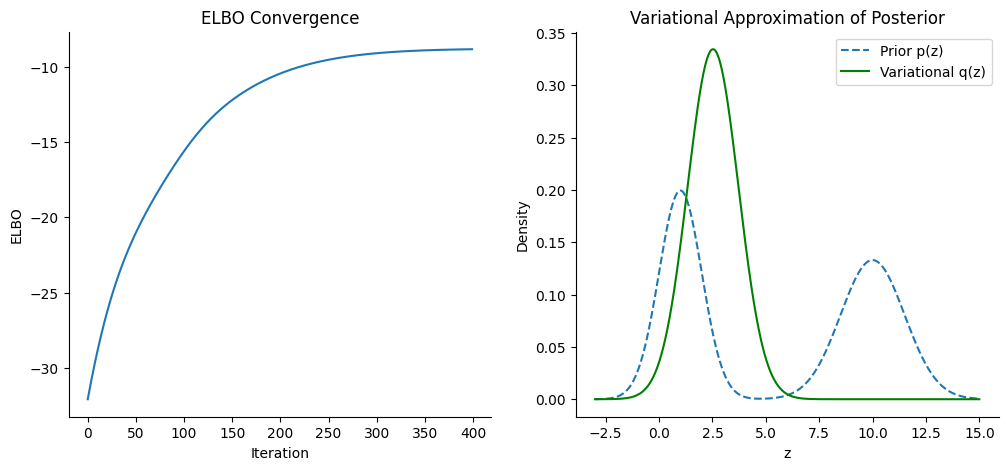

Optimized Variational Mean (mu): 2.528
Optimized Variational Std (sigma): 1.193


In [2]:
# Define a bimodal prior distribution p(z) ~ 0.5*N(1,1) + 0.5*N(10,1.5)
# It serves as both true distribution and prior in this demo.
ptrue = distrax.MixtureSameFamily(
    mixture_distribution=distrax.Categorical(probs=[0.5, 0.5]),
    components_distribution=distrax.Normal(loc=[1, 10], scale=[1, 1.5]),
)

# Define likelihood function p(x | z) ~ N(z, 0.5)
likelihood_std = 0.5
def log_likelihood(x, z):
    return distrax.Normal(z, likelihood_std).log_prob(x)

def kl_sampling_inverse(params, p, samples=100000):
    q = distrax.Normal(loc=params[0], scale=params[1])  # Variational distribution q(z)
    sample_set = q.sample(seed=jax.random.PRNGKey(0), sample_shape=samples)  # Monte Carlo samples
    return jnp.mean(q.log_prob(sample_set) - p.log_prob(sample_set))  # Estimate KL(q || p)

# Define ELBO function for multiple observations
# variational mean-field approximation
def elbo(params, x_batch, samples=1000):
    #mu and sigma are vectors, each pair of elements in the vectors are independent
    mu, log_sigma = params
    sigma = jnp.exp(log_sigma)
    q_z = distrax.Normal(mu, sigma) #match mean-field assumption

    # Sample from q(z)
    z_samples = q_z.sample(seed=jax.random.PRNGKey(0), sample_shape=(samples,))

    # Compute expected log-likelihood for all x in x_batch
    log_lik = jnp.mean(jax.vmap(log_likelihood, in_axes=(0, None))(x_batch, z_samples))

    # Compute KL divergence
    kl = kl_sampling_inverse(params, ptrue, samples)

    return log_lik - kl  # ELBO objective

# Optimization function for VI
def fit_vi(params, optimizer, n_itr, x_batch):
    opt_state = optimizer.init(params)
    loss = []
    for i in range(n_itr):
        loss_value, grads = jax.value_and_grad(lambda p: -elbo(p, x_batch))(params)  # Compute ELBO for batch
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        loss.append(-loss_value)  # Store ELBO
    return params, loss

# Define multiple observed values
x_obs = jnp.array([1.5, 2.0, 3.0, 4.5])  # Multiple observed values

# Initialize parameters and optimizer
params = jnp.array([5.0, 1.0])  # Initial (mu, log_sigma)
optimizer = optax.adam(learning_rate=0.01)
n_itr = 400  # Number of iterations

# Train using multiple observations
opt_params, loss_history = fit_vi(params, optimizer, n_itr, x_obs)

# Extract optimized variational parameters
mu_opt, log_sigma_opt = opt_params
sigma_opt = jnp.exp(log_sigma_opt)

# Compare learned q(z) to prior
z_vals = jnp.linspace(-3, 15, 1000)
q_approx = distrax.Normal(mu_opt, sigma_opt).prob(z_vals)
prior_vals = ptrue.prob(z_vals)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve
ax1.plot(loss_history)
ax1.set_title("ELBO Convergence")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("ELBO")

# Posterior approximation
ax2.plot(z_vals, prior_vals, label="Prior p(z)", linestyle="--")
ax2.plot(z_vals, q_approx, label="Variational q(z)", color="green")
ax2.set_title("Variational Approximation of Posterior")
ax2.set_xlabel("z")
ax2.set_ylabel("Density")
ax2.legend()

sns.despine()
plt.show()

# Print optimized parameters
print(f"Optimized Variational Mean (mu): {mu_opt:.3f}")
print(f"Optimized Variational Std (sigma): {sigma_opt:.3f}")

# Good: Increasing and stabilizing
# Bad: Decreasing or fluctuating wildly, Flat (constant ELBO), Nan